<a href="https://colab.research.google.com/github/Stecklert1/UST--Deep-Learning-2026/blob/main/Deep_Learning_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import pandas as pd
Path="/content/drive/MyDrive/train.csv"



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import imageio.v2 as imageio
from IPython.display import Image

In [ ]:
df = pd.read_csv(Path)
df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [ ]:
df.shape

(76020, 371)

In [ ]:
from sklearn import preprocessing
import numpy as np # Import numpy for boolean indexing

# Assuming 'y' was intended to be the 'TARGET' column
if 'TARGET' in df.columns:
    y = df['TARGET']
else:
    print("Error: 'TARGET' column not found in the DataFrame 'df'.")
    print("Please ensure 'df' contains a 'TARGET' column.")
    # You might need to adjust 'x' to align with 'y' if 'x' had 'var3' dropped earlier
    # and 'y' is still from the original 'df'.

# Create an instance of MinMaxScaler and ensure consistent naming
min_max_scaler = preprocessing.MinMaxScaler()

# 'x' is already defined from `x= df.drop('var3', axis=1)`
# Ensure 'x' and 'y' have the same index for correct alignment

# Fit the scaler on the 'normal' data (where TARGET is 0)

# Let's re-align x and y from the df to be safe, dropping ID and TARGET from X for scaling
X_data = df.drop(columns=['ID', 'TARGET'], errors='ignore')
Y_data = df['TARGET']

# Handle potential missing values in X_data before fitting the scaler
# You might want to use SimpleImputer here, as done in the autoencoder preprocessing step
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_data)

# Convert back to DataFrame for easier filtering if needed, or use numpy arrays for indexing
X_imputed_df = pd.DataFrame(X_imputed, columns=X_data.columns)

# Fit the scaler on the data where Y_data is 0 (normal data)
min_max_scaler.fit(X_imputed_df[Y_data == 0])

# Transform the entire imputed dataset
X_scaled_all = min_max_scaler.transform(X_imputed_df)

# Now, create X_sat and X_unsat using the scaled data and the original Y_data for filtering
X_sat = X_scaled_all[Y_data == 0]
X_unsat = X_scaled_all[Y_data == 1]

print("Shape of X_scaled_all:", X_scaled_all.shape)
print("Shape of X_sat (TARGET=0):")
print(X_sat.shape)
print("Shape of X_unsat (TARGET=1):")
print(X_unsat.shape)

# Display first few rows of X_sat and X_unsat
print("First 5 rows of X_sat:")
print(X_sat[:5])
print("First 5 rows of X_unsat:")
print(X_unsat[:5])

Shape of X_scaled_all: (76020, 369)
Shape of X_sat (TARGET=0):
(73012, 369)
Shape of X_unsat (TARGET=1):
(3008, 369)
First 5 rows of X_sat:
[[0.99976406 0.18       0.         ... 0.         0.         0.00154526]
 [0.99976406 0.29       0.         ... 0.         0.         0.0020025 ]
 [0.99976406 0.18       0.         ... 0.         0.         0.00282212]
 [0.99976406 0.32       0.         ... 0.         0.         0.00267115]
 [0.99976406 0.34       0.         ... 0.         0.         0.00509076]]
First 5 rows of X_unsat:
[[0.99976406 0.61       0.         ... 0.         0.         0.00264014]
 [0.99976406 0.4        0.         ... 0.         0.         0.00543926]
 [0.99976406 0.37       0.         ... 0.         0.         0.0029246 ]
 [0.99976406 0.26       0.         ... 0.         0.         0.00182035]
 [0.99976406 0.57       0.         ... 0.         0.         0.00474053]]


In [ ]:
# Define the autoencoder model
input_dim = X_scaled_all.shape[1] # Using the input_dim from the previous preprocessing step
encoding_dim = 32  # You can adjust this value

# Encoder
encoder = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(encoding_dim, activation='relu')
])

# Decoder
decoder = Sequential([
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu', input_shape=(encoding_dim,)),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='linear') # Output layer should have the same dimensions as input
])

# Autoencoder
autoencoder = Sequential([encoder, decoder])

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Display model summary
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ (None, 32)             │        58,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ (None, 369)            │        58,985 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,633 (459.50 KB)

 Trainable params: 117,633 (459.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from scipy.sparse import rand
import numpy as np # Import numpy for random operations

N_samples_x_norm = 10000

# Ensure that X_sat is defined and not empty
if 'X_sat' in locals() and X_sat.shape[0] > 0:
    # Generate random indices for X_sat
    random_indices_x_norm_subset = np.random.choice(X_sat.shape[0], size=min(N_samples_x_norm, X_sat.shape[0]), replace=False)

    # Select the subset of X_sat using these random indices
    x_norm_subset = X_sat[random_indices_x_norm_subset]
    print("Shape of x_norm_subset:", x_norm_subset.shape)
    print("First 5 rows of x_norm_subset:")
    print(x_norm_subset[:5])
else:
    print("Error: X_sat is not defined or is empty. Please ensure data preprocessing has been completed.")

Shape of x_norm_subset: (10000, 369)
First 5 rows of x_norm_subset:
[[0.99976406 0.18       0.         ... 0.         0.         0.0040333 ]
 [0.99976406 0.69       0.         ... 0.         0.         0.00509076]
 [0.99976406 0.17       0.         ... 0.         0.         0.00244202]
 [0.99976406 0.67       0.         ... 0.         0.         0.00917403]
 [0.99976406 0.21       0.         ... 0.         0.         0.00509076]]


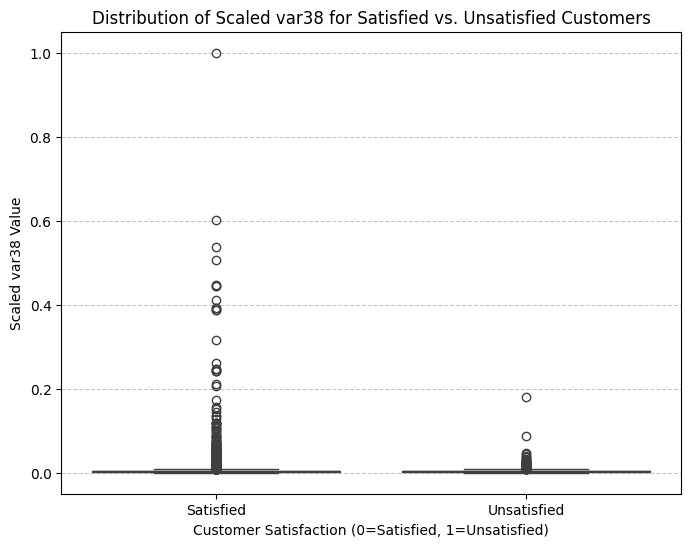

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.impute import SimpleImputer # Import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'TARGET' column exists
if 'TARGET' in df.columns:
    Y_data = df['TARGET'] # Define Y_data
else:
    print("Error: 'TARGET' column not found in the DataFrame 'df'.")
    print("Please ensure 'df' contains a 'TARGET' column.")
    # Exit or handle the error appropriately if 'TARGET' is crucial
    # For now, let's assume it exists and proceed.

# Let's re-align X and Y from the df to be safe, dropping ID and TARGET from X for scaling
X_data = df.drop(columns=['ID', 'TARGET'], errors='ignore')

# Handle potential missing values in X_data before fitting the scaler
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_data)

# Convert back to DataFrame for easier filtering if needed, or use numpy arrays for indexing
X_imputed_df = pd.DataFrame(X_imputed, columns=X_data.columns) # Define X_imputed_df

# Create an instance of MinMaxScaler and ensure consistent naming
min_max_scaler = preprocessing.MinMaxScaler()

# Fit the scaler on the data where Y_data is 0 (normal data)
min_max_scaler.fit(X_imputed_df[Y_data == 0])

# Transform the entire imputed dataset
X_scaled_all = min_max_scaler.transform(X_imputed_df) # Define X_scaled_all

# Reconstruct a DataFrame for plotting using a relevant feature and the TARGET variable
# Let's pick 'var38' as an example, as it often shows significant differences

# Get the index of 'var38' in the scaled data
if 'var38' in X_imputed_df.columns:
    var38_idx = X_imputed_df.columns.get_loc('var38')
else:
    print("Warning: 'var38' not found in features. Using the first feature for plotting.")
    var38_idx = 0 # Fallback to first feature

plot_df = pd.DataFrame({
    'var38_scaled': X_scaled_all[:, var38_idx],
    'TARGET': Y_data.values
})

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='var38_scaled', data=plot_df)
plt.title('Distribution of Scaled var38 for Satisfied vs. Unsatisfied Customers')
plt.xlabel('Customer Satisfaction (0=Satisfied, 1=Unsatisfied)')
plt.ylabel('Scaled var38 Value')
plt.xticks([0, 1], ['Satisfied', 'Unsatisfied'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
print("Training the autoencoder...")
# Train the autoencoder on the entire scaled dataset
# Using a portion of X_scaled_all as validation data
autoencoder.fit(X_scaled_all, X_scaled_all,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_split=0.2,
                verbose=0) # Set verbose to 0 to suppress output for each epoch
print("Autoencoder training complete.")

Training the autoencoder...
Autoencoder training complete.


2376/2376 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


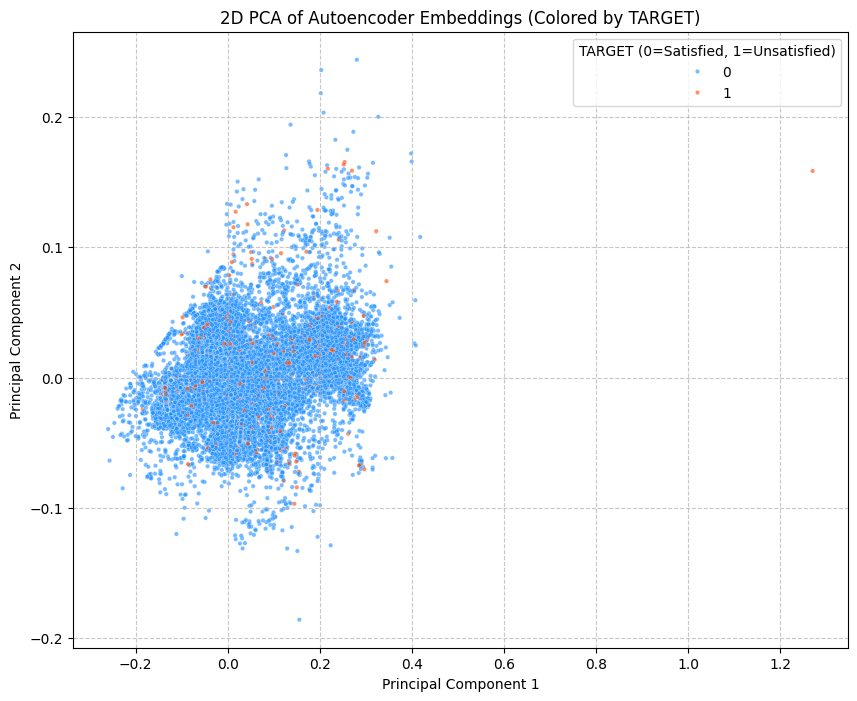

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the encoded representations from the trained encoder
encoded_data = encoder.predict(X_scaled_all)

# Apply PCA for dimensionality reduction to 2 components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(encoded_data)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])
pca_df['TARGET'] = Y_data.values

# Define a custom color palette for brighter, bolder blue and a contrasting color
custom_palette = {0: '#1E90FF', 1: '#FF4500'} # Dodger Blue for TARGET=0, Orange Red for TARGET=1

# Visualize the embedding space with the custom color palette
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='TARGET',
                data=pca_df, palette=custom_palette, alpha=0.6, s=10)
plt.title('2D PCA of Autoencoder Embeddings (Colored by TARGET)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='TARGET (0=Satisfied, 1=Unsatisfied)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

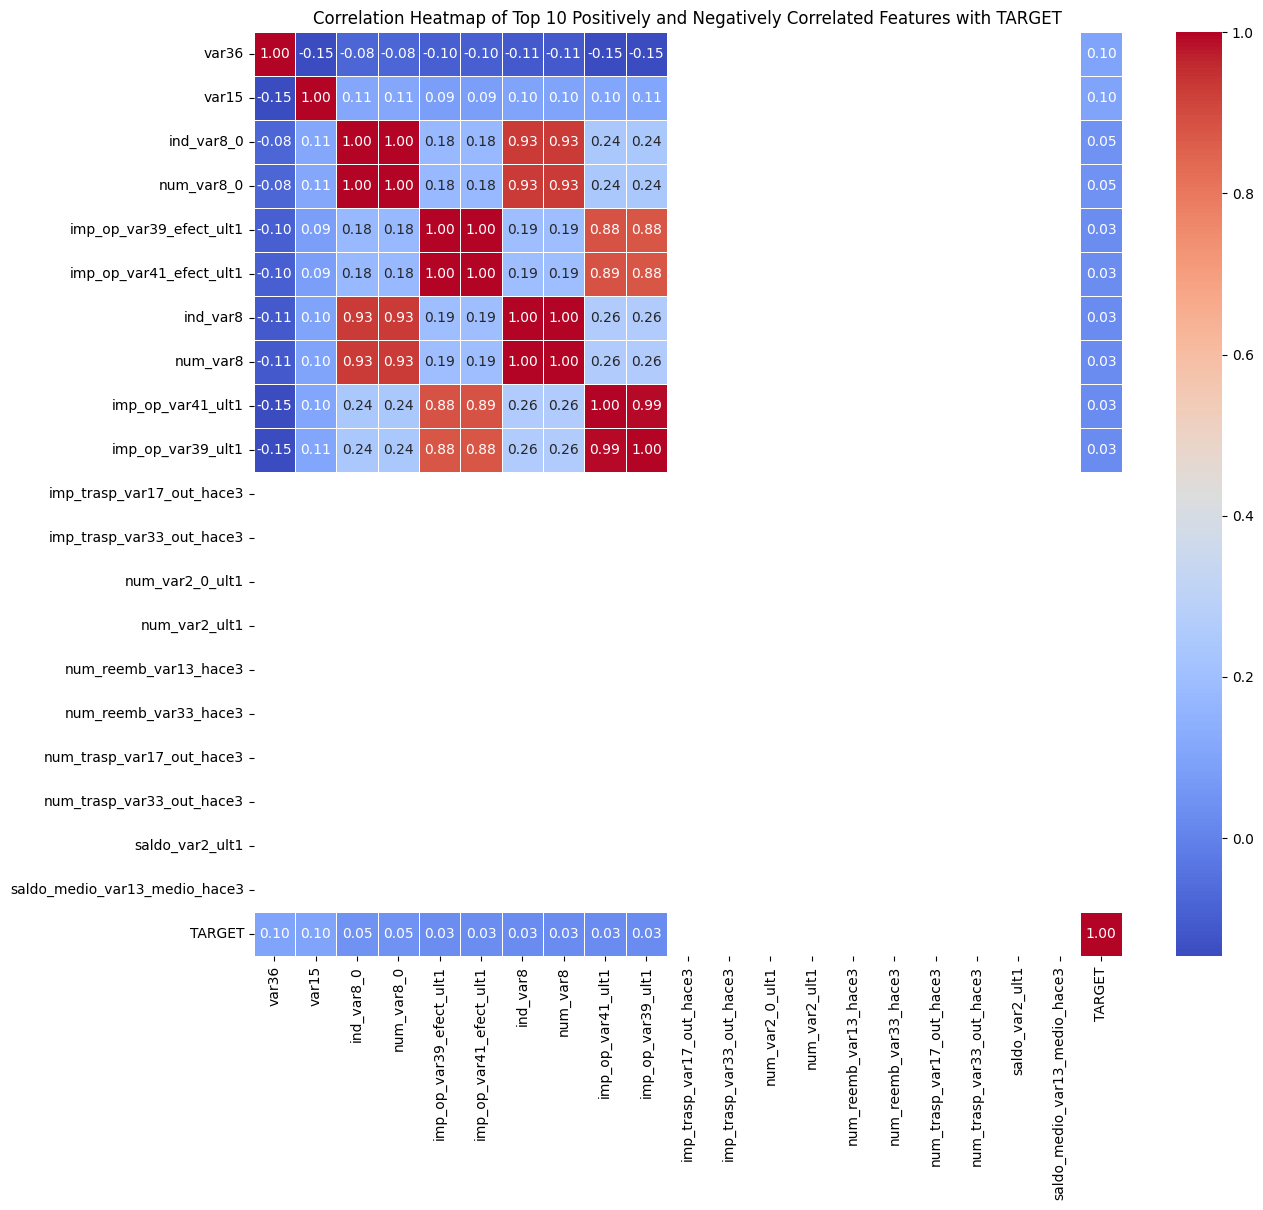

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure combined_df is created as it contains all scaled features and the TARGET
# Assuming X_scaled_all, X_imputed_df.columns, and Y_data are available from previous executions
combined_df = pd.DataFrame(X_scaled_all, columns=X_imputed_df.columns)
combined_df['TARGET'] = Y_data.values

# Calculate correlations of all features with the TARGET variable
correlations_with_target = combined_df.corr()['TARGET'].sort_values(ascending=False)

# Get the top 10 most positively correlated features (excluding TARGET itself)
top_positive_features = correlations_with_target.head(11).iloc[1:].index.tolist()

# Get the top 10 most negatively correlated features
top_negative_features = correlations_with_target.tail(10).index.tolist()

# Combine these features and include 'TARGET' itself for the heatmap
selected_features = top_positive_features + top_negative_features + ['TARGET']

# Create a correlation matrix for these selected features
correlation_matrix = combined_df[selected_features].corr()

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Top 10 Positively and Negatively Correlated Features with TARGET')
plt.show()
